# 03 - Acquisition Model Validation

## Objective
Determine whether the scoring engine varies sensibly, reconciles to persisted results, resists adversarial cases, and avoids unexpected component dominance.

## Data source
Official scoring component and acquisition-score views, plus scoring weights and calibrated segment rules stored in PostgreSQL.

## Methodology
Reuse the scoring `score_scenario` and segmentation functions. Validate persisted outputs, component correlations and influence, monotonic directions, deliberately difficult synthetic cases, and retained outliers.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'database').exists() and (path / 'python').exists())
sys.path.insert(0, str(REPO_ROOT))

from python.analysis.data_access import load_analysis_inputs
from python.model_validation.diagnostics import (
    base_case_reconciliation, component_influence, monotonicity_tests,
    outlier_review, score_correlations,
)
from python.model_validation.sensitivity import default_weight_map, segment_thresholds
from python.model_validation.stress_tests import run_stress_tests

In [2]:
inputs = load_analysis_inputs(['component_scores', 'acquisition_scores', 'scoring_weights', 'segment_rules'])
weights = default_weight_map(inputs['scoring_weights'])
thresholds = segment_thresholds(inputs['segment_rules'])
reconciliation = base_case_reconciliation(inputs['component_scores'], inputs['acquisition_scores'], weights, thresholds)
correlations = score_correlations(inputs['acquisition_scores'])
influence = component_influence(inputs['acquisition_scores'], weights, thresholds)
monotonicity = monotonicity_tests(inputs['component_scores'])
stress = run_stress_tests(inputs['component_scores'], weights, thresholds)
outliers = outlier_review(inputs['acquisition_scores'])

print('Maximum acquisition-score difference:', reconciliation['acquisition_score_abs_diff'].max())
print('Exact rank matches:', int(reconciliation['rank_equal'].sum()), '/', len(reconciliation))
print('Exact segment matches:', int(reconciliation['segment_equal'].sum()), '/', len(reconciliation))
display(influence)

Maximum acquisition-score difference: 0.004986702635655149
Exact rank matches: 120 / 120
Exact segment matches: 120 / 120


,dimension,score_column,weight_pct,component_score_std,weighted_contribution_std,acquisition_spearman,mean_abs_rank_change_when_neutralized,max_abs_rank_change_when_neutralized,top10_overlap_when_neutralized,dominance_review
0,DEMAND,demand_score,30.0,24.450,7.335,0.8260,9.467,65,8,Largest weighted contribution spread
1,REVENUE,revenue_score,25.0,26.580,6.645,0.8799,9.950,38,8,Largest ranking displacement when neutralized
2,COMPETITION,competition_score,15.0,20.792,3.119,-0.1409,6.300,27,9,Contextual contributor; inspect jointly with c...
3,FEASIBILITY,feasibility_score,15.0,16.873,2.531,0.4459,5.333,22,8,Contextual contributor; inspect jointly with c...
4,STRATEGIC_FIT,strategic_fit_score,15.0,16.565,2.485,0.5424,5.133,21,9,Contextual contributor; inspect jointly with c...


In [3]:
display(correlations[correlations['right_metric'].eq('acquisition_score')])
display(stress)
display(monotonicity)
display(outliers[['test_id', 'parking_id', 'parking_name', 'metric', 'value', 'treatment']].head(30))

,left_metric,right_metric,n,pearson,spearman
5,demand_score,acquisition_score,120,0.8816,0.8260
10,revenue_score,acquisition_score,120,0.8937,0.8799
14,competition_score,acquisition_score,120,-0.1759,-0.1409
17,strategic_fit_score,acquisition_score,120,0.5486,0.5424
19,feasibility_score,acquisition_score,120,0.4381,0.4459
20,attractiveness_score,acquisition_score,120,0.9855,0.9775


,test_id,test_name,case,records_tested,observed_metric,rank_or_score,expected,priority_segment,status
0,TEST_A,Test A Huge Low Occupancy,Synthetic huge lot with low occupancy,1,32.250,100,Huge capacity with very low occupancy does not...,AVOID,PASS
1,TEST_B,Test B Small High Utilization,Synthetic small lot with strong utilization,1,76.145,4,"Small, highly utilised, high-demand lot has a ...",ACQUIRE_NOW,PASS
2,TEST_C,Test C High Price Weak Demand,Synthetic expensive lot with weak demand,1,30.689,105,High price with weak demand does not become a ...,AVOID,PASS
3,TEST_D,High demand + extreme competition,Extreme pressure vs thin competition twin,2,11.250,25 vs 7,Extreme competition lowers the composite versu...,NaN,PASS
4,TEST_E,Test E High Demand Low Feasibility,Synthetic high-demand lot with unwilling owner,1,61.682,23,Low feasibility materially blocks an otherwise...,PURSUE,PASS
5,TEST_F,Moderate economics + major network gap,Network-gap twin comparison,2,10.500,31 vs 55,Strategic fit creates a visible score and rank...,NaN,PASS


,test_id,description,records_tested,violations,minimum_delta,maximum_delta,status
0,MONO-DEMAND,Increasing demand multiplier does not reduce D...,120,0,0.000000,20.010766,PASS
1,MONO-REVENUE,Increasing commission does not reduce Revenue ...,120,0,0.000000,23.063897,PASS
2,MONO-COST,Increasing onboarding cost does not improve Fe...,120,0,-4.882175,0.000000,PASS
3,MONO-FEASIBILITY,Increasing owner willingness does not reduce F...,120,0,20.000000,20.000000,PASS
4,MONO-COMPETITION,Increasing competitor count does not improve C...,120,0,-55.000000,-38.297278,PASS


,test_id,parking_id,parking_name,metric,value,treatment
0,EXTREME_ACQUISITION_SCORE,52,MCD Parking,acquisition_score,78.530000,Retained; scoring continuous inputs use 5th/95...
1,EXTREME_ACQUISITION_SCORE,18,OSM Parking node-786590777,acquisition_score,76.930000,Retained; scoring continuous inputs use 5th/95...
2,EXTREME_ACQUISITION_SCORE,1,OSM Parking node-928559154,acquisition_score,76.210000,Retained; scoring continuous inputs use 5th/95...
3,EXTREME_HIGH_OCCUPANCY,18,OSM Parking node-786590777,avg_occupancy_rate,0.671702,Retained; scoring continuous inputs use 5th/95...
4,EXTREME_HIGH_OCCUPANCY,55,OSM Parking way-1270655678,avg_occupancy_rate,0.624339,Retained; scoring continuous inputs use 5th/95...
5,EXTREME_HIGH_OCCUPANCY,52,MCD Parking,avg_occupancy_rate,0.619881,Retained; scoring continuous inputs use 5th/95...
6,EXTREME_HIGH_PRICES,3,Palika Parking,hourly_rate_inr,125.000000,Retained; scoring continuous inputs use 5th/95...
7,EXTREME_HIGH_PRICES,8,OSM Parking node-5634145022,hourly_rate_inr,125.000000,Retained; scoring continuous inputs use 5th/95...
8,EXTREME_HIGH_PRICES,7,OSM Parking way-1237304338,hourly_rate_inr,105.000000,Retained; scoring continuous inputs use 5th/95...
9,EXTREME_LARGE_LOTS,45,OSM Parking way-80414548,capacity_cars,706.000000,Retained; scoring continuous inputs use 5th/95...


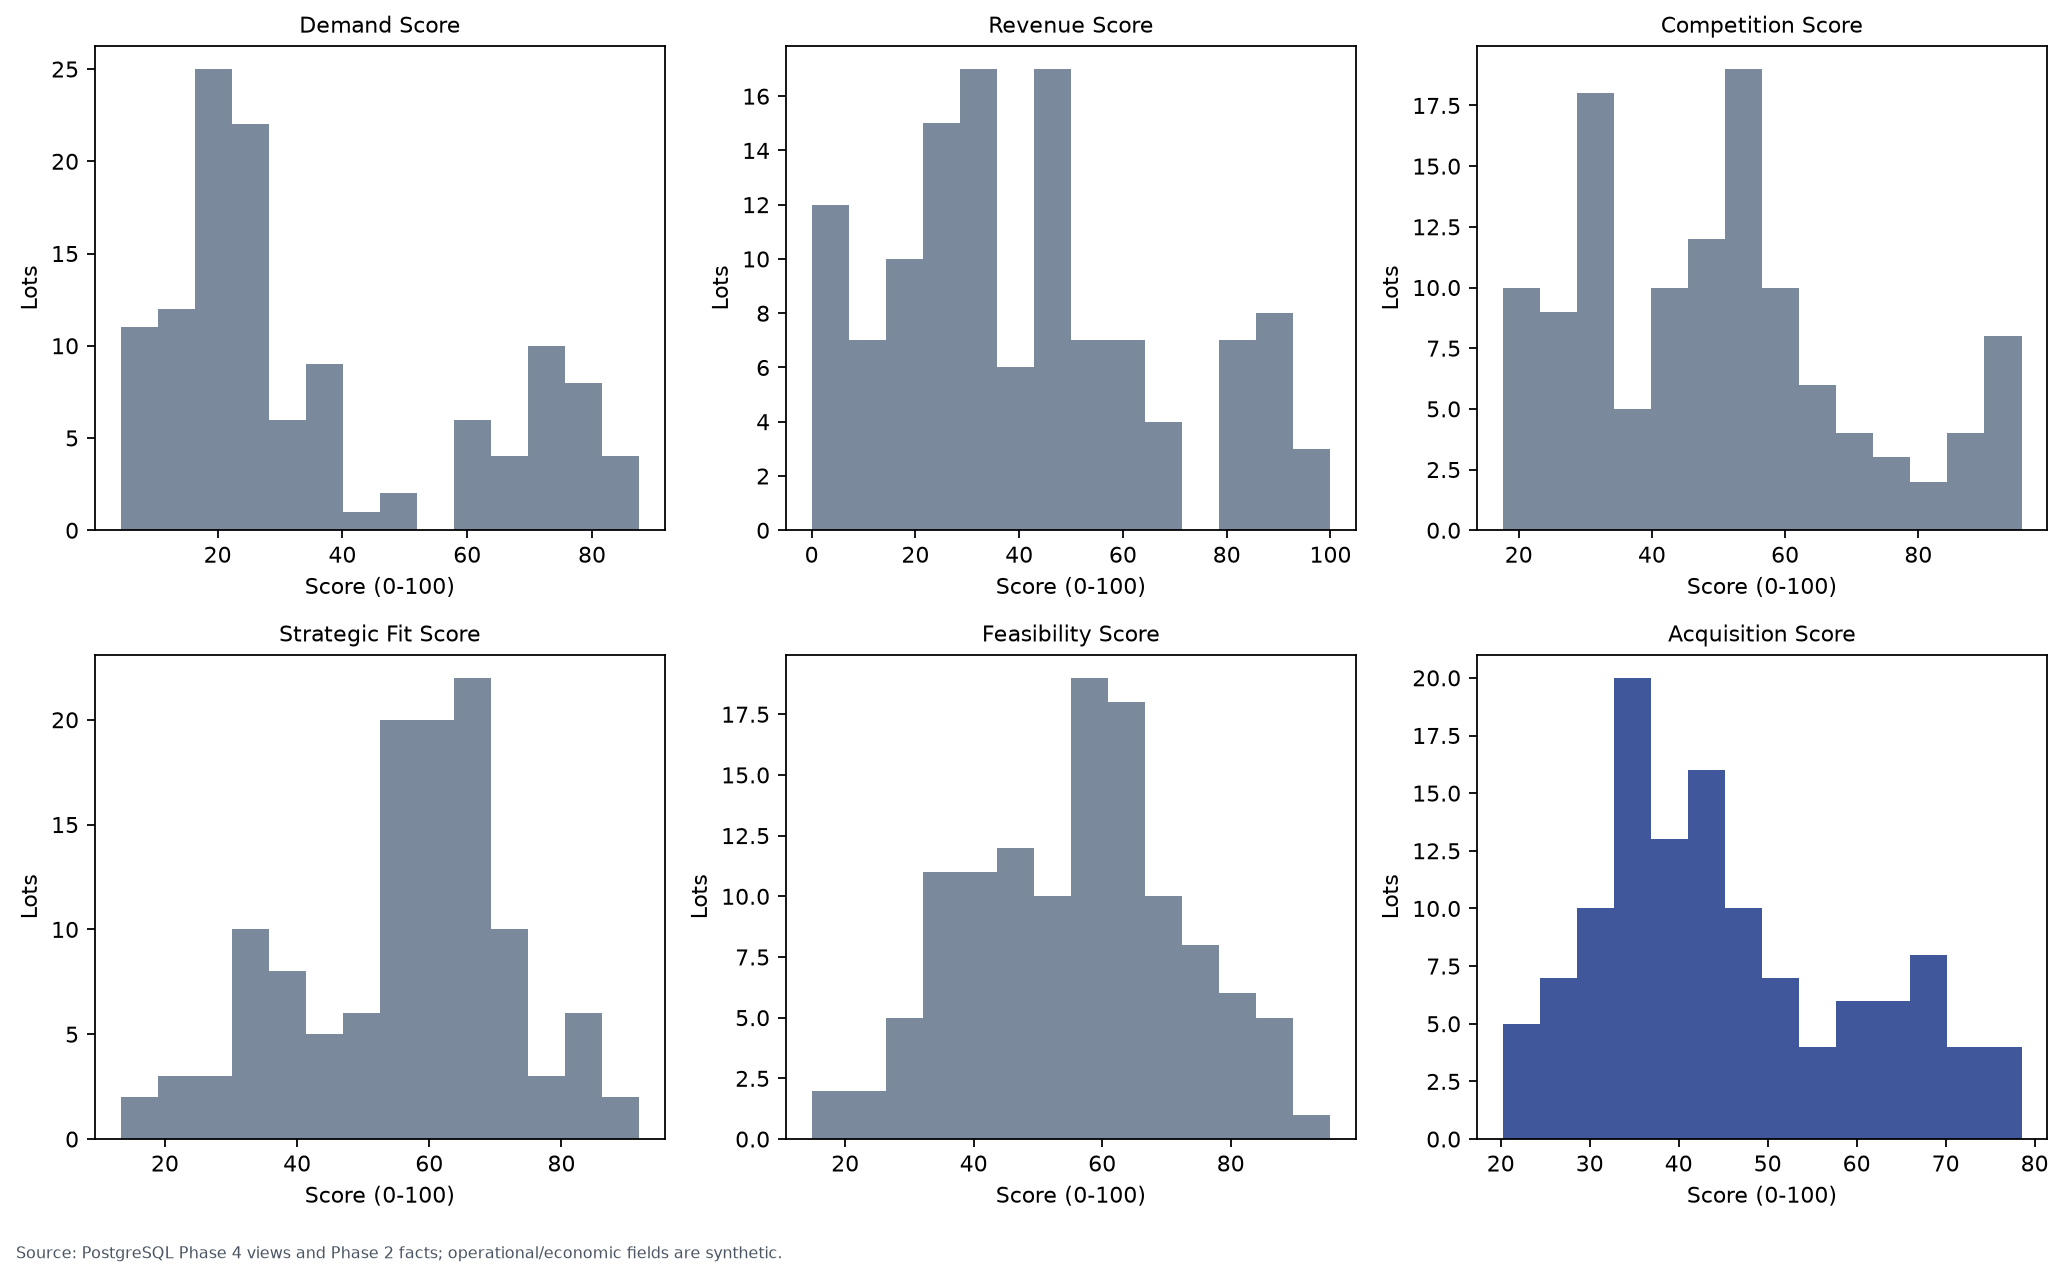

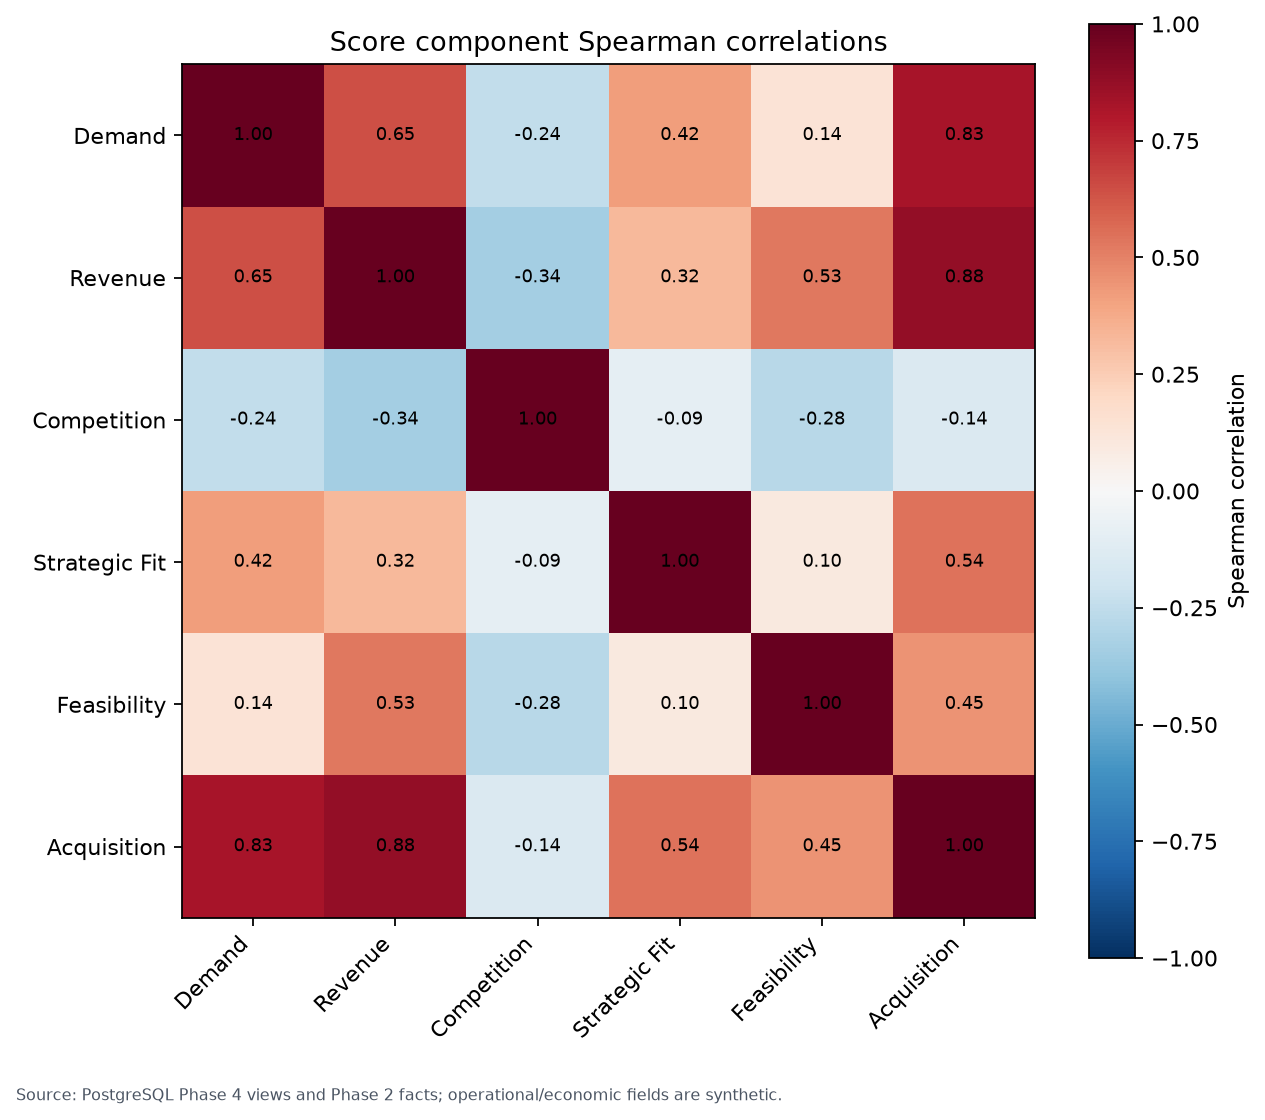

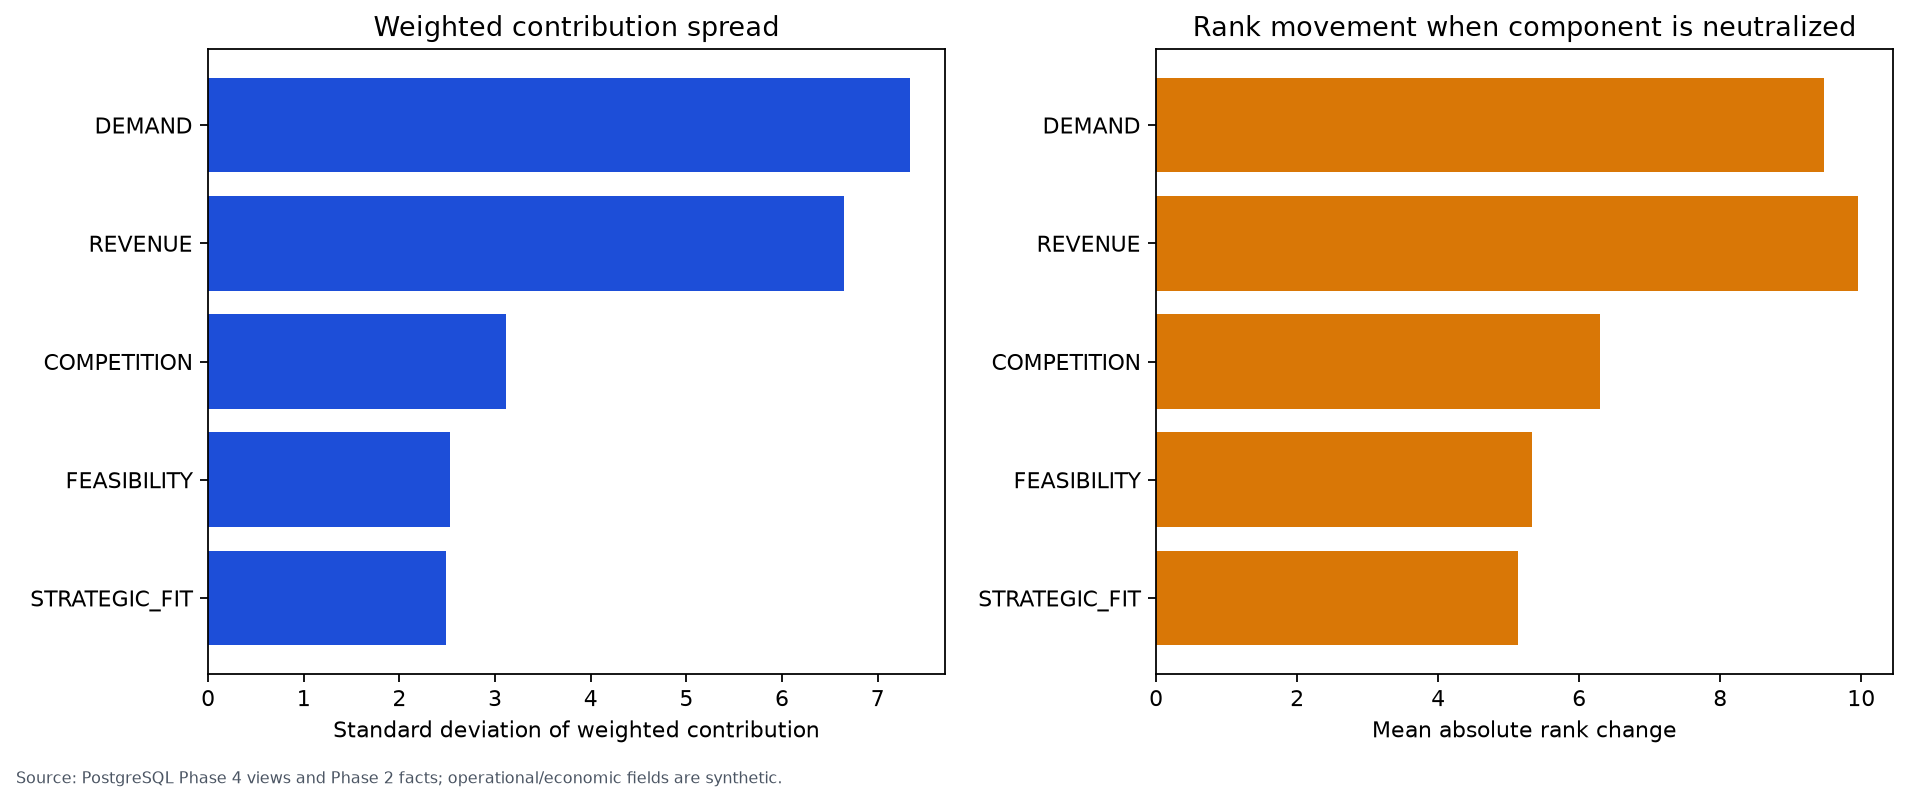

In [4]:
for filename in ['07_score_distributions.png', '08_score_correlations.png', '09_component_influence.png']:
    display(Image(filename=REPO_ROOT / 'validation' / 'figures' / filename, width=900))

## Key findings

- The validation base rerun reproduces all 120 the scoring engine ranks and segments; the maximum score difference is 0.005 and is explained by persisted two-decimal rounding.
- Revenue has the highest rank correlation with the final acquisition score (Spearman 0.88), followed by demand (0.83). Revenue produces the largest average displacement when neutralised (9.95 ranks), while demand has the widest weighted contribution spread. Neither alone explains the full ranking.
- Competition is negatively correlated with the final score in this realised dataset (-0.14) because high-demand markets also contain more competitors; the opportunity component remains directionally correct in controlled monotonic tests.
- All six adversarial stress tests pass, including huge/low-utilisation, small/high-utilisation, price-without-demand, extreme competition, low owner willingness, and network-gap cases.
- All five monotonicity tests pass with zero violations.
- Outliers are schema-plausible synthetic or derived values. They are retained; the score transforms already use 5th/95th percentile anchors where appropriate.

## Limitations

There are no real acquisition outcomes, so this validates internal logic and robustness rather than predictive accuracy. Thresholds and percentile anchors are relative to the current 120-lot population and should be recalibrated when real data or a materially different candidate universe is introduced.